## Notebook 1: SETUP 

<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
In this notebook, we load the packages, set seeds read reference grid (shape, transform, CRS).
</blockquote>

In [1]:
import sys
import importlib
import importlib.metadata as im

import numpy as np, pandas as pd
import climada as cl
import xarray as xr, rasterio, geopandas as gpd

print("Python:", sys.version.split()[0])
print("Kernel exe:", sys.executable)
print("climada module path:", getattr(cl, "__file__", "<none>"))

try:
    print("CLIMADA:", cl.__version__)
except AttributeError:
    try:
        print("CLIMADA:", im.version("climada"))
    except im.PackageNotFoundError:
        print("CLIMADA: <not found in package metadata>")

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("xarray:", xr.__version__)
print("rasterio:", rasterio.__version__)
print("geopandas:", gpd.__version__)

Python: 3.10.19
Kernel exe: /opt/anaconda3/envs/urbanheat/bin/python
climada module path: /opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/climada/__init__.py
CLIMADA: 6.1.0
NumPy: 1.26.4
Pandas: 2.1.4
xarray: 2025.6.1
rasterio: 1.4.3
geopandas: 1.1.1


In [2]:
# Generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# Choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: rome  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim


In [3]:
# Generic Drive sync (city-aware) 
from pathlib import Path
import json, gdown
from datetime import datetime

CFG_PATH = C["CFG"]          # Path to configs/<slug>.yml
cfg      = C["cfg"]          # dict loaded from YAML
base_dir = Path(C["BASE"]).resolve()

# drive_manifest is relative to repo root in YAML
manifest_path = (ROOT / cfg["drive_manifest"]).resolve()
M = json.loads(Path(manifest_path).read_text())

def _append_log(path: Path, line: str):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "a") as fh:
        fh.write(line + "\n")

def _sidecar(p: Path) -> Path:
    return p.with_suffix(p.suffix + ".synced")

def _need(dest: Path, force: bool) -> bool:
    sc = _sidecar(dest)
    return force or (not dest.exists()) or (not sc.exists())

def _note_ok(dest: Path, id_: str):
    sc = _sidecar(dest)
    sc.write_text(json.dumps({"id": id_, "size": dest.stat().st_size if dest.exists() else None,
                              "when": datetime.now().isoformat()}))

def sync_from_gdrive(M, base_dir: Path, use_cookies=True, force=False, only=None):
    base_dir.mkdir(parents=True, exist_ok=True)
    failures = []
    def _selected(rel): return True if not only else any(rel.startswith(pfx) for pfx in only)

    for e in M["entries"]:
        if not _selected(e["dest"]): 
            continue
        e_type, e_id = e.get("type", "file"), e["id"]
        dest = (base_dir / e["dest"]).resolve()
        dest.parent.mkdir(parents=True, exist_ok=True)
        try:
            if e_type == "folder":
                marker = dest / ".synced.ok"
                needs = force or (not dest.exists()) or (not any(dest.iterdir())) or (not marker.exists())
                if needs:
                    print(f"↻ Folder: {e_id} → {dest}")
                    gdown.download_folder(id=e_id, output=str(dest), quiet=False,
                                          use_cookies=use_cookies, remaining_ok=True)
                    marker.write_text(json.dumps({"id": e_id, "when": datetime.now().isoformat()}))
                else:
                    print(f"✓ Folder up-to-date: {dest}")
            else:
                if _need(dest, force):
                    print(f"↻ File:   {e_id} → {e['dest']}")
                    url = f"https://drive.google.com/uc?id={e_id}"
                    out = gdown.download(url=url, output=str(dest), quiet=False, use_cookies=use_cookies)
                    if out is None or not dest.exists():
                        raise RuntimeError("gdown returned None or file missing.")
                    _note_ok(dest, e_id)
                else:
                    print(f"✓ File up-to-date: {e['dest']}")
        except Exception as ex:
            errlog = (dest if e_type == "file" else (dest/".folder")).with_suffix(".sync_errors.log")
            _append_log(errlog, f"[{datetime.now().isoformat()}] {e_type.upper()} {e_id} → {dest} FAILED: {ex}")
            print(f"✗ FAIL {e_type} {dest} — {ex}")
            failures.append({"type": e_type, "id": e_id, "dest": str(dest), "error": str(ex)})

    if failures:
        print("\n=== SUMMARY: failures that need attention ===")
        for f in failures:
            print(f"- {f['type']} → {f['dest']} :: {f['error']}\n"
                  f"  Action: check Drive item and update ID in {manifest_path}")
    else:
        print("\nAll entries synced successfully.")

print(f"→ Syncing Drive for {cfg['city_name']} (slug={SLUG}) from {manifest_path}")
sync_from_gdrive(M, base_dir, use_cookies=True, force=False)

# checks from YAML (city-agnostic)
for rel in [cfg["ac"]["gridded_file"], cfg["ac"]["penetration_file"], cfg["files"]["gvi_csv"]]:
    p = base_dir / rel
    print(("OK  " if p.exists() else "MISS"), p)

→ Syncing Drive for Rome (slug=rome) from /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data_manifests/rome_gdrive.json
✓ File up-to-date: CAPZONE/CAPZONE.shp
✓ File up-to-date: CAPZONE/CAPZONE.shx
✓ File up-to-date: CAPZONE/CAPZONE.dbf
✓ File up-to-date: CAPZONE/CAPZONE.prj
✓ File up-to-date: CAPZONE/CAPZONE.cpg
✓ File up-to-date: CAPZONE/CAPZONE.sbn
✓ File up-to-date: CAPZONE/CAPZONE.sbx
✓ File up-to-date: CAPZONE/CAPZONE.shp.xml
✓ File up-to-date: UrbClim/UrbClimWBGTmax/UrbClimWBGTmax.zip
✓ File up-to-date: fua/rome_fua_ghs_4326.dbf
✓ File up-to-date: fua/rome_fua_ghs_4326.geojson
✓ File up-to-date: fua/rome_fua_ghs_4326.prj
✓ File up-to-date: fua/rome_fua_ghs_4326.shp
✓ File up-to-date: fua/rome_fua_ghs_4326.shx
✓ File up-to-date: gviRome/gvi_Rome.csv
✓ File up-to-date: LCZ/00_global_map_of_LCZs.png
✓ File up-to-date: LCZ/lcz_filter_v3.tif
✓ File up-to-date: LCZ/lcz_v3.tif
✓ File up-to-date: hazard/impact_geo_curpol_rome_urbclim-WBGT-dayover28_0.5_absolute_2030_0.001

## Loading packages and main data 

In [4]:
import os, sys, glob, textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# geospatial packages 
import rasterio
from rasterio.plot import show
from rasterio.enums import Resampling
import geopandas as gpd
from rasterio.mask import mask
import rasterio as rio

# for the netCDF 
import xarray as xr

plt.rcParams["figure.dpi"] = 130

p_LCZ     = P("LCZ")
p_UrbClim = P("UrbClim/UrbClimWBGTmax")   
gvi_csv = P(cfg["files"]["gvi_csv"])
p_GVI   = gvi_csv.parent 
p_CoolEff = P("CoolingEff")              
p_FUA     = P("fua")
p_CAP     = P("CAPZONE")

In [5]:
# CoolingEff
coolingeff_csvs = sorted(p_CoolEff.glob("*.csv"))
print("CoolingEff CSVs:", [f.name for f in coolingeff_csvs] or "none (folder is empty)")

# UrbClim
nc_files = sorted(p_UrbClim.glob("WBGT_year_daily_max_*.nc"))
print(f"UrbClim .nc files found: {len(nc_files)}")
for f in nc_files[:6]:
    print(" •", f.name)

CoolingEff CSVs: ['outer_2_max.csv', 'outer_2_mean.csv', 'outer_2_min.csv', 'outer_2_wbgt_max.csv', 'outer_2_wbgt_mean.csv', 'outer_2_wbgt_min.csv']
UrbClim .nc files found: 10
 • WBGT_year_daily_max_2008.nc
 • WBGT_year_daily_max_2009.nc
 • WBGT_year_daily_max_2010.nc
 • WBGT_year_daily_max_2011.nc
 • WBGT_year_daily_max_2012.nc
 • WBGT_year_daily_max_2013.nc


**Rome FUA Boundaries**

In [6]:
from pathlib import Path

p_FUA = P("fua")

# making it city agnostic
candidates = list(p_FUA.glob(f"*{SLUG}*_ghs_4326.*"))
prio = {".geojson": 0, ".gpkg": 1, ".shp": 2}
candidates = sorted(candidates, key=lambda p: prio.get(p.suffix.lower(), 99))
assert candidates, f"No FUA file found for {SLUG} in {p_FUA}"
fua_path = candidates[0]

fua = gpd.read_file(fua_path)
print("FUA CRS:", fua.crs)
display(fua.head())

FUA CRS: EPSG:4326


,name,iso,efua_id,geometry
0,Rome,ITA,3881.0,"POLYGON ((12.31402 41.71339, 12.27812 41.71339..."


**Inspecting datasets**

**LCZ rasters**

In [7]:
list(p_LCZ.glob("*")) # listing files, the important one is lcz_filter_v3

[PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/00_global_map_of_LCZs.png.synced'),
 PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/00_global_map_of_LCZs.png'),
 PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/lcz_filter_v3.tif'),
 PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/lcz_v3.tif.synced'),
 PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/lcz_v3.tif'),
 PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/lcz_filter_v3.tifgipeihah.part'),
 PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/lcz_filter_v3.tif.synced')]

In [8]:
lcz_path = P("LCZ/lcz_filter_v3.tif")

with rasterio.open(lcz_path) as src:
    # align FUA CRS to the raster’s CRS (according to the Readme the LCZ is EPSG:4326, but just to be sure)
    fua_aligned = fua.to_crs(src.crs)
    geoms = [g.__geo_interface__ for g in fua_aligned.geometry if g is not None]

    # masking + cropping to the minimal bounding window around the FUA
    out, out_transform = mask(src, geoms, crop=True, filled=True)
    lcz_fua = out[0]                       # single-band raster 
    lcz_meta = src.meta.copy()
    lcz_meta.update({"transform": out_transform,
                     "height": lcz_fua.shape[0],
                     "width":  lcz_fua.shape[1]})
    nodata_val = src.nodata

print("LCZ masked shape:", lcz_fua.shape, "| nodata:", nodata_val)

LCZ masked shape: (655, 896) | nodata: 0.0


Map of masked LCZ

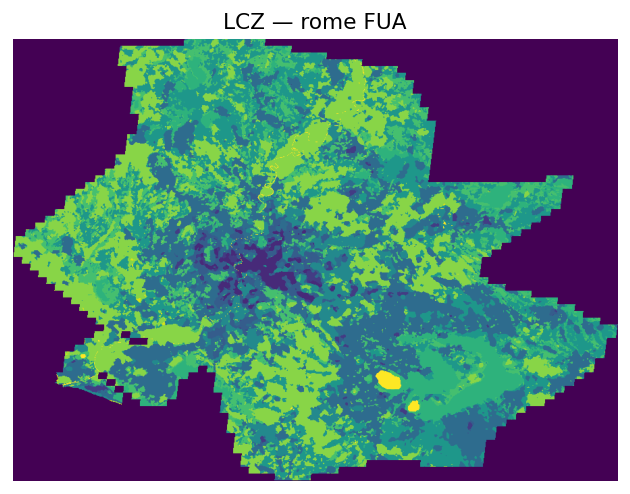

In [9]:
plt.figure(figsize=(6,5))
plt.imshow(lcz_fua, origin="upper")
plt.title(f"LCZ — {CITY} FUA")
plt.axis("off")
plt.show()

Counting pixels by LCZ class and computing shares

In [10]:
# treating nodata/zeros as invalid. LCZ classes are 1..17 (1-10:built-up, 11-17:natural)
valid = np.isfinite(lcz_fua) & (lcz_fua > 0)
vals = lcz_fua[valid].astype(int)

uniq, cnt = np.unique(vals, return_counts=True)

lcz_names = { # mapping of lcz names to numbers based on the article 
    1:"Compact highrise",  2:"Compact midrise",  3:"Compact lowrise",
    4:"Open highrise",     5:"Open midrise",     6:"Open lowrise",
    7:"Lightweight low-rise", 8:"Large lowrise", 9:"Sparsely built",
    10:"Heavy industry",
    11:"Dense trees", 12:"Scattered trees", 13:"Bush, scrub",
    14:"Low plants",  15:"Bare rock/paved", 16:"Bare soil/sand", 17:"Water"
}

df_lcz = (pd.DataFrame({"LCZ": uniq, "pixels": cnt})
            .assign(name=lambda d: d["LCZ"].map(lcz_names),
                    share_pct=lambda d: 100 * d["pixels"] / d["pixels"].sum())
            .sort_values("LCZ")
            .reset_index(drop=True))

display(df_lcz)

,LCZ,pixels,name,share_pct
0,2,4720,Compact midrise,1.307838
1,3,2990,Compact lowrise,0.828482
2,4,127,Open highrise,0.035190
3,5,9410,Open midrise,2.607363
4,6,85610,Open lowrise,23.721187
5,8,21185,Large lowrise,5.870031
6,9,77450,Sparsely built,21.460179
7,10,11,Heavy industry,0.003048
8,11,26606,Dense trees,7.372105
9,12,45412,Scattered trees,12.582952


Interesting to understand what LCZ categories are there: we don't have compact highrise, expected for Roma, and no lightweight lowrise

Built categories only shares (no natural)

In [11]:
# Calculating the shares over just the built LCZ classes (from 1 to 10)
built_mask = df_lcz["LCZ"].between(1, 10)
built_total = df_lcz.loc[built_mask, "pixels"].sum()

df_lcz_built = (df_lcz.loc[built_mask, ["LCZ","name","pixels"]]
                    .assign(share_pct_within_built=lambda d: 100 * d["pixels"] / built_total)
                    .reset_index(drop=True))

print("Shares over BUILT classes only (1–10):")
display(df_lcz_built)

Shares over BUILT classes only (1–10):


,LCZ,name,pixels,share_pct_within_built
0,2,Compact midrise,4720,2.342397
1,3,Compact lowrise,2990,1.483849
2,4,Open highrise,127,0.063026
3,5,Open midrise,9410,4.669906
4,6,Open lowrise,85610,42.485720
5,8,Large lowrise,21185,10.513491
6,9,Sparsely built,77450,38.436152
7,10,Heavy industry,11,0.005459


**GVI**

In [12]:
# Opening the gvi_city csv : current level of green space (measured by a metric called GVI) in city, measured per pixel
# Since it's not spatially continuous (vectors and not rasters), would be interesting to define some areas in city and calculate 
# the spatial average of the current adaptation intensity from SGS in those regions  
# GVI (city-aware)
gvi_csv = P(cfg["files"]["gvi_csv"])   # from YAML
print("GVI file:", gvi_csv)

gvi = pd.read_csv(gvi_csv)

# sanity check 
display(gvi.head())
gvi.info()

# check 
need_cols = {"x", "y", "lcz_filter_v3", "gvi"}
missing = need_cols - set(gvi.columns)
assert not missing, f"GVI CSV missing columns: {missing}"

GVI file: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/gviRome/gvi_Rome.csv


,Unnamed: 0,x,y,lcz_filter_v3,gvi
0,1,12.351697,41.915007,6,18.299756
1,2,12.352030,41.915886,6,14.004485
2,3,12.352051,41.919640,6,19.536704
3,4,12.359077,41.921091,6,29.173072
4,5,12.360293,41.915526,6,17.205097


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3458 entries, 0 to 3457
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     3458 non-null   int64  
 1   x              3458 non-null   float64
 2   y              3458 non-null   float64
 3   lcz_filter_v3  3458 non-null   int64  
 4   gvi            3458 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 135.2 KB


What could be the scale ?

- GVI is a point sample, and we have 3458 points
- We use UrbClim data, LCZ classes, and cost/benefit analysis at the city scale
- We need regions: actionable for policy, compatible with LCZ and UrbClim, statistically stable given GVI sample density

- For now I chose the municipi, also because the boundaries are accessible through OSM  

UrbClim DATA

Some of the UrbClim: data for the example of Rome - We can aggregate them to the monthly average of the climatological period for mean, max, min (I do it later with max WBGT)

In [13]:
# inspecting a few UrbClim NetCDF files (metadata only)

print("UrbClim folder:", p_UrbClim)

nc_files = sorted(p_UrbClim.rglob("*.nc"))
print(f"Found {len(nc_files)} NetCDF file(s).")

# picking a small sample to inspect 
N = 6
sample = nc_files[:N]
for i, f in enumerate(sample, 1):
    print("\n" + "="*100)
    print(f"[{i}/{len(sample)}] FILE: {f.name}")
    try:
        # open, not loading arrays into memory
        ds = xr.open_dataset(f, decode_times=True)
    except Exception as e:
        print("Could not open dataset:", e)
        continue

    # Basic structure
    print("  ─ dims:", dict(ds.sizes))
    print("  ─ coords:", list(ds.coords))
    print("  ─ data_vars:", list(ds.data_vars))

    # show time coverage if present
    if "time" in ds.coords:
        try:
            t0 = ds["time"].isel(time=0).values
            t1 = ds["time"].isel(time=-1).values
            print("  ─ time range:", t0, "→", t1, f"({ds.sizes.get('time', 'no time')} steps)")
        except Exception as e:
            print("  ─ time coordinate present but could not summarize:", e)

    # guess a main variable and show its attributes
    main_var = None
    # prefer commonly named vars
    for cand in ["t2m","wbgt","T2M","WBGT","temperature","wbgt_max","wbgt_min","wbgt_mean"]:
        if cand in ds.data_vars:
            main_var = cand
            break
    if main_var is None and len(ds.data_vars) > 0:
        main_var = list(ds.data_vars)[0]

    if main_var:
        da = ds[main_var]
        print(f"  ─ main var: {main_var}  (dtype={da.dtype}, dims={da.dims}, shape={tuple(da.shape)})")
        # print a few attributes without dumping everything
        attrs_preview = {k: da.attrs[k] for k in list(da.attrs)[:6]}
        print("  ─ attrs (preview):", attrs_preview)
        # show a tiny numeric peek if 1D or we can safely slice
        try:
            if "time" in da.dims:
                peek = da.isel({d:0 for d in da.dims if d != "time"}).isel(time=0).values
            else:
                peek = da.isel({d:0 for d in da.dims}).values
            arr = np.array(peek)
            if arr.size <= 9:
                print("  ─ tiny peek:", arr)
            else:
                print("  ─ tiny peek: OK (omitted; not scalar)")
        except Exception as e:
            print("  ─ peek failed:", e)

    # Close to release file handle
    ds.close()

if not sample:
    print("No .nc files to inspect. Double-check p_UrbClim.")

UrbClim folder: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/UrbClim/UrbClimWBGTmax
Found 10 NetCDF file(s).

[1/6] FILE: WBGT_year_daily_max_2008.nc
  ─ dims: {'x': 301, 'y': 301, 'time': 366}
  ─ coords: ['x', 'y', 'time']
  ─ data_vars: ['WBGT']
  ─ time range: 2008-01-01T00:00:00.000000000 → 2008-12-31T00:00:00.000000000 (366 steps)
  ─ main var: WBGT  (dtype=float64, dims=('time', 'y', 'x'), shape=(366, 301, 301))
  ─ attrs (preview): {'units': '°C'}
  ─ tiny peek: 7.53

[2/6] FILE: WBGT_year_daily_max_2009.nc
  ─ dims: {'x': 301, 'y': 301, 'time': 365}
  ─ coords: ['x', 'y', 'time']
  ─ data_vars: ['WBGT']
  ─ time range: 2009-01-01T00:00:00.000000000 → 2009-12-31T00:00:00.000000000 (365 steps)
  ─ main var: WBGT  (dtype=float64, dims=('time', 'y', 'x'), shape=(365, 301, 301))
  ─ attrs (preview): {'units': '°C'}
  ─ tiny peek: 13.040000000000001

[3/6] FILE: WBGT_year_daily_max_2010.nc
  ─ dims: {'x': 301, 'y': 301, 'time': 365}
  ─ coords: ['x', 'y', '

In [14]:
# Monthly baseline climatology using the WBGT_max CDF from 2008 to 2017
wbgt_max_dir   = P("UrbClim/UrbClimWBGTmax")
wbgt_max_files = sorted(wbgt_max_dir.glob("WBGT_year_daily_max_*.nc"))

assert wbgt_max_files, "No WBGT_year_daily_max_*.nc files found."

ds = xr.open_mfdataset(
    wbgt_max_files,
    combine="by_coords",
    decode_times=True,
    chunks={"time": 90}  # keeps memory tame
)

vname = next((v for v in ("WBGT","wbgt","WBGT_max") if v in ds.data_vars), list(ds.data_vars)[0])
da = ds[vname]

# Monthly mean of daily WBGT_max, then 2008–2017 climatology

# monthly time series (mean of daily maxima within each month)
monthly_ts = da.resample(time="MS").mean()   # "MS" = month start, monthly mean of the daily maxima

# + optional : FUA mask on UrbClim grid => the one we will use later because we put the mask on all the data 
from affine import Affine
import rasterio.features as rfeat
from rasterio.crs import CRS
import numpy as np

crs_laea = CRS.from_epsg(3035)
fua_laea = fua.to_crs(crs_laea)

# the x and y are the coordinates of the centers of each grid cell
# to rasterize polygon (FUA) onto grid we give Affine transform to map pixel indices to real-world coordinates at pixel corners
x = ds["x"].values
y = ds["y"].values
dx = float(np.diff(x).mean()); dy = float(np.diff(y).mean())

# build affine for this grid: cell centers at x,y -> shift by half a pixel
transform = Affine.translation(float(x.min()) - dx/2, float(y.min()) - dy/2) * Affine.scale(dx, dy)
geom_list = [g for g in fua_laea.geometry if g is not None]

mask = rfeat.geometry_mask(
    geom_list,
    out_shape=(len(y), len(x)),
    transform=transform,
    invert=True  # True = inside polygons is True
)
fua_mask = xr.DataArray(mask, coords={"y": ds["y"], "x": ds["x"]}, dims=("y","x"))

# climatology: average those monthly means across all years, per month
clim_monthly = monthly_ts.groupby("time.month").mean("time")  # 12 maps

# city-mean seasonal cycle
city_monthly_mean = clim_monthly.mean(dim=("y","x"))
city_monthly_mean_FUA = (clim_monthly.where(fua_mask)).mean(dim=("y","x"))    # FUA only

clim_monthly, city_monthly_mean, city_monthly_mean_FUA

(<xarray.DataArray 'WBGT' (month: 12, y: 301, x: 301)> Size: 9MB
 dask.array<stack, shape=(12, 301, 301), dtype=float64, chunksize=(1, 100, 100), chunktype=numpy.ndarray>
 Coordinates:
   * x        (x) float64 2kB 4.512e+06 4.513e+06 ... 4.542e+06 4.542e+06
   * y        (y) float64 2kB 2.073e+06 2.073e+06 ... 2.103e+06 2.103e+06
   * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
 Attributes:
     units:    °C,
 <xarray.DataArray 'WBGT' (month: 12)> Size: 96B
 dask.array<mean_agg-aggregate, shape=(12,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
 Coordinates:
   * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12,
 <xarray.DataArray 'WBGT' (month: 12)> Size: 96B
 dask.array<mean_agg-aggregate, shape=(12,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
 Coordinates:
   * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12)

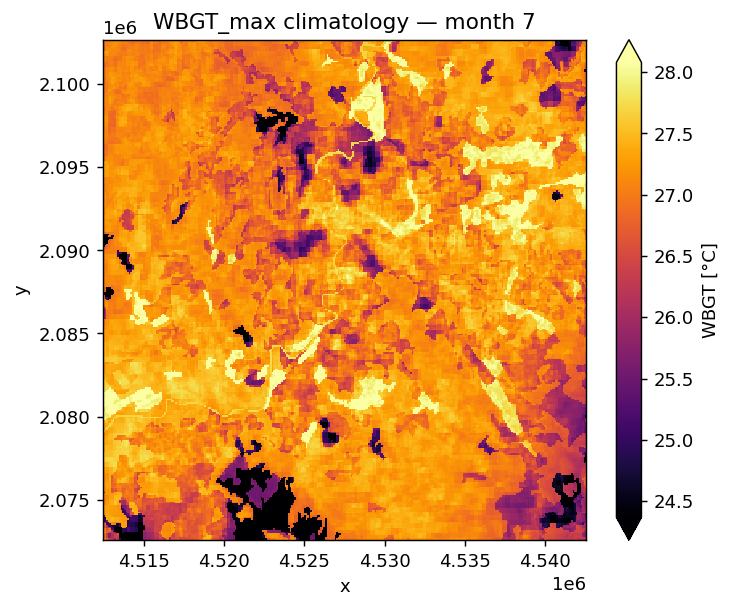

In [15]:
# July
month_to_show = 7  # (July) # 1..12
ax = clim_monthly.sel(month=month_to_show).plot.imshow(
    x="x", y="y", robust=True, cmap="inferno", figsize=(6,5)
)
ax.axes.set_title(f"WBGT_max climatology — month {month_to_show}")
plt.show()

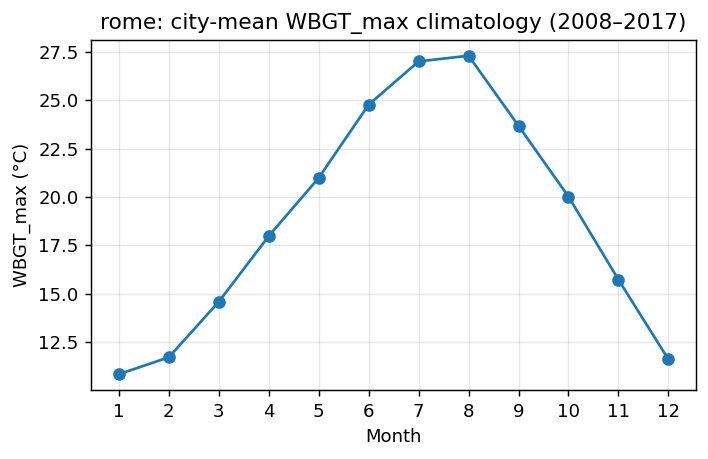

,month,WBGT_max_C
0,1,10.836833
1,2,11.712188
2,3,14.582953
3,4,17.977085
4,5,20.986793
5,6,24.772281
6,7,27.008720
7,8,27.305006
8,9,23.680360
9,10,20.019200


In [16]:
# climatology
fig, ax = plt.subplots(figsize=(6,3.5))
ax.plot(range(1,13), city_monthly_mean.values, marker="o")
ax.set_xticks(range(1,13)); ax.set_xlabel("Month")
ax.set_ylabel("WBGT_max (°C)")
ax.set_title(f"{CITY}: city-mean WBGT_max climatology (2008–2017)")
ax.grid(True, alpha=0.3)
plt.show()

display(pd.DataFrame({"month": range(1,13), "WBGT_max_C": city_monthly_mean.values}))

These numbers seem to make sense : highest WBGT max months are July and August, lowest January and December. Important also to note that WBGT is not just the temperature, so it's normal that the maximum seems lower than maximal temperatures we experience. 

**Cooling Efficiency of street trees csv**: Each coefficient tells you: by how much increasing the level of green space (measured by GVI) will change the heat metric (here attached, for the monthly average of minimum, mean, and maximum of 1) air temperature and 2) wet-bulb globe temperature (WBGT) in that city and in that LCZ) in each month of the year. Specifically, the variable "coef" will give you how many Celsius degrees will a 1 unit increase in GVI drive.

Each of the CSV gives a city (UC_NM_MN), a month, a lcz class, a coeff, coef_abs 

In [17]:
print("CoolingEff folder:", p_CoolEff) # printing the path to the folder, what is inside ? 6 csv

coolingeff_csvs = sorted(p_CoolEff.glob("*.csv"))
if not coolingeff_csvs:
    print("No CSV files found in CoolingEff.")
else:
    print(f"Found {len(coolingeff_csvs)} CSV file(s):")
    for i, f in enumerate(coolingeff_csvs, 1):
        print(f"  {i:2d}. {f.name}")

    # reading and displaying heads: looking at the first rows of each of these 6 csv 
    coolingeff = {}
    for f in coolingeff_csvs:
        print("\n" + "="*90)
        print(f"FILE: {f.name}")
        try:
            df = pd.read_csv(f)
        except Exception as e:
            print("Could not read CSV:", e)
            continue
        coolingeff[f.stem] = df
        print(f"  shape: {df.shape}")
        print(f"  columns: {list(df.columns)}")
        display(df.head(5)) # showing the head of each of these 6 csv 

CoolingEff folder: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/CoolingEff
Found 6 CSV file(s):
   1. outer_2_max.csv
   2. outer_2_mean.csv
   3. outer_2_min.csv
   4. outer_2_wbgt_max.csv
   5. outer_2_wbgt_mean.csv
   6. outer_2_wbgt_min.csv

FILE: outer_2_max.csv
  shape: (10872, 6)
  columns: ['Unnamed: 0', 'UC_NM_MN', 'month', 'lcz', 'coef', 'coef_abs']


,Unnamed: 0,UC_NM_MN,month,lcz,coef,coef_abs
0,1,Accra_max,1,Compact lowrise,0.074672,0.023864
1,2,Accra_max,2,Compact lowrise,0.074637,0.023864
2,3,Accra_max,3,Compact lowrise,0.074191,0.023864
3,4,Accra_max,4,Compact lowrise,0.075146,0.023864
4,5,Accra_max,5,Compact lowrise,0.078642,0.023864



FILE: outer_2_mean.csv
  shape: (10872, 6)
  columns: ['Unnamed: 0', 'UC_NM_MN', 'month', 'lcz', 'coef', 'coef_abs']


,Unnamed: 0,UC_NM_MN,month,lcz,coef,coef_abs
0,1,Accra,1,Compact lowrise,0.015239,0.004262
1,2,Accra,2,Compact lowrise,0.015121,0.004262
2,3,Accra,3,Compact lowrise,0.014896,0.004262
3,4,Accra,4,Compact lowrise,0.014972,0.004262
4,5,Accra,5,Compact lowrise,0.015449,0.004262



FILE: outer_2_min.csv
  shape: (11064, 6)
  columns: ['Unnamed: 0', 'UC_NM_MN', 'month', 'lcz', 'coef', 'coef_abs']


...

,Unnamed: 0,UC_NM_MN,month,lcz,coef,coef_abs
0,1,Accra_max_wbgt,1,Compact lowrise,-0.026608,-0.007932
1,2,Accra_max_wbgt,2,Compact lowrise,-0.026713,-0.007932
2,3,Accra_max_wbgt,3,Compact lowrise,-0.026638,-0.007932
3,4,Accra_max_wbgt,4,Compact lowrise,-0.026394,-0.007932
4,5,Accra_max_wbgt,5,Compact lowrise,-0.026809,-0.007932



FILE: outer_2_wbgt_mean.csv
  shape: (10872, 6)
  columns: ['Unnamed: 0', 'UC_NM_MN', 'month', 'lcz', 'coef', 'coef_abs']


,Unnamed: 0,UC_NM_MN,month,lcz,coef,coef_abs
0,1,Accra_wbgt,1,Compact lowrise,-0.012626,-0.003293
1,2,Accra_wbgt,2,Compact lowrise,-0.012363,-0.003293
2,3,Accra_wbgt,3,Compact lowrise,-0.012189,-0.003293
3,4,Accra_wbgt,4,Compact lowrise,-0.012197,-0.003293
4,5,Accra_wbgt,5,Compact lowrise,-0.012444,-0.003293



FILE: outer_2_wbgt_min.csv
  shape: (11064, 6)
  columns: ['Unnamed: 0', 'UC_NM_MN', 'month', 'lcz', 'coef', 'coef_abs']


,Unnamed: 0,UC_NM_MN,month,lcz,coef,coef_abs
0,1,Accra_min_wbgt,1,Compact lowrise,-0.018787,-0.00449
1,2,Accra_min_wbgt,2,Compact lowrise,-0.018208,-0.00449
2,3,Accra_min_wbgt,3,Compact lowrise,-0.017870,-0.00449
3,4,Accra_min_wbgt,4,Compact lowrise,-0.017920,-0.00449
4,5,Accra_min_wbgt,5,Compact lowrise,-0.018287,-0.00449


In [18]:
lcz_out = OUTP("lcz_masked_fua.tif")
with rasterio.open(lcz_out, "w", **lcz_meta) as dst:
    dst.write(lcz_fua, 1)
print("Saved:", lcz_out)

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/lcz_masked_fua.tif
